# Proteomics minibulk analysis 

In this tutorial, we reanalyse minibulk DVP data from Nordmann et al., 2024. Here, the authors dissected Keratinocytes from formalin-fixed, paraffin-embedded archived skin tissue biopsies of three types of cutaneous drug reactions with increasing severity (Healthy, maculopapular rash/MPR, drug reaction with eosinophilia and systemic symptoms/DRESS, Toxic epidermal necrolysis/TEN). 

We reanalyse the data from the original publication. We will 

1. Load the data from a DIANN report
2. Add metadata
3. Perform standard feature-level filtering 
4. Log2-transform the data to increase normality and homoskedasticity
5. Impute the data with a Gaussian imputation strategy
6. Visualize the cohort properties via unsupervised principal component analysis 
7. Perform differential expression analysis between healthy and diseased tissues.

## Modules

Here, we will leverage analysis tools built on top of the scverse-ecosystem and the `anndata` data structure, including alphapepttools, a software package for the analysis of MS-proteomics data, and decoupler, as these tools are directly interoperable with the spatialdata framework we used in the [image analysis tutorial](../image-analysis/harpy.ipynb). 

Note that openDVP provides similar functionalities for the analysis of DVP data in Python, which can be checked out in [this vignette](https://coscialab.github.io/openDVP/Tutorials/T2_DownstreamProteomics.html). Other packages like MSstats or scp offer similar analysis functionality in R but are incompatible with the spatialdata framework.

In [1]:
import warnings
from collections.abc import Callable

import alphapepttools as apt
import anndata as ad
import decoupler as dc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import median_abs_deviation

/Users/lucas-diedrich/mamba/envs/npdvp-at/lib/python3.13/site-packages/mudata/__init__.py:30: DeprecationWarning: The decorator_name argument is deprecated and will be removed in the future.
  register_mudata_namespace = _make_register_namespace_decorator(MuData, "mdata", "register_mudata_namespace", "numpy")
/Users/lucas-diedrich/mamba/envs/npdvp-at/lib/python3.13/site-packages/mudata/__init__.py:30: DeprecationWarning: The docstring_style argument is deprecated and will be removed in the future.
  register_mudata_namespace = _make_register_namespace_decorator(MuData, "mdata", "register_mudata_namespace", "numpy")
/Users/lucas-diedrich/mamba/envs/npdvp-at/lib/python3.13/site-packages/Bio/__init__.py:138: BiopythonWarning: You may be importing Biopython from inside the source tree. This is bad practice and might lead to downstream issues. In particular, you might encounter ImportErrors due to missing compiled C extensions. We recommend that you try running your code from outside the so

## Functions

We define a helper function to aggregate multiple replicate measurements into a patient-level representation.

In [2]:
def agg(
    adata, group_column: str, func: Callable | None = None, layer: str | None = None
) -> ad.AnnData:
    """Pseudobulk an anndata object based on a group column in adata.obs"""
    if func is None:

        def func(x):
            return np.nanmean(x, axis=0)

    groupings = adata.obs.groupby(group_column, observed=True).indices

    rows = []
    for _, indices in groupings.items():
        with warnings.catch_warnings(record=True):
            warnings.simplefilter("always", RuntimeWarning)
            rows.append(func(adata.layers[layer][indices, :]))

    return ad.AnnData(
        X=np.stack(rows),
        obs=pd.DataFrame(index=groupings.keys()),
        var=adata.var,
    )


def mad_outlier(
    adata: ad.AnnData,
    column: str,
    *,
    nmad: float = 3,
    key_added: str = "mad_outlier",
    copy: bool = False,
) -> ad.AnnData | None:
    adata = adata.copy() if copy else adata
    data = adata.obs[column]

    median = data.median(skipna=True)
    mad = median_abs_deviation(data, nan_policy="omit")

    adata.obs[key_added] = (data < median - nmad * mad) | (data > median + nmad * mad)

    return adata if copy else None

## Parameters

In [3]:
COLOR_MAP = {
    "Healthy": "#999FA3",
    "MPR": "#9CBFDB",
    "DRESS": "#F9BF8F",
    "TEN": "#CBA7CE",
}
ORDER = ["Healthy", "MPR", "DRESS", "TEN"]

## Proteomics Data Analysis

### Ingest data
We load the DIANN report into an `anndata` object and add the relevant metadata:

In [4]:
adata = apt.io.read_pg_table(
    "../../data/dvp_proteomics_keratinocytes.tsv", search_engine="diann"
)
metadata = pd.read_csv(
    "../../data/metadata_keratinocytes.tsv", sep="\t", index_col="sample_id"
)

adata = apt.pp.add_metadata(adata, metadata, axis=0)
adata.obs["sample_id"] = (
    adata.obs["patient_id"] + "-" + adata.obs["replicate_nr"].astype(str)
)

### Log-transform data

MS-proteomics data is typically analysed in log-space. We backup the raw intensities and log-transform the data. 

In [5]:
# Save raw intensities
adata.layers["raw"] = adata.X.copy()

apt.pp.nanlog(adata)

### Sample-level quality control

Sample preparation and mass-spectrometric measurement are major drivers of technical variation between samples. Because label-free proteomics quantifies protein abundances relative to each other across samples, failed samples — for example due to missed injections or sample degradation — distort normalization and propagate into all downstream results. Such samples can typically be identified by a markedly lower number of confidently quantified features than the rest of the cohort. We therefore first compute the feature completeness per sample, i.e. the fraction of proteins with non-missing values:

In [6]:
apt.metrics.fraction_complete(adata, axis=0)

Rather than choosing a fixed cutoff, we flag outliers using a data-driven threshold based on the median absolute deviation (MAD). A sample is considered an outlier when its completeness deviates from the cohort median by more than a defined number of MADs (here, three), which adapts the threshold to the observed spread of the data.

In [7]:
mad_outlier(adata, "fraction_complete", nmad=3, key_added="mad_outlier__completeness")
adata.obs["mad_outlier__completeness"].value_counts(normalize=True)

mad_outlier__completeness
False    1.0
Name: proportion, dtype: float64

None of the samples were flagged as outliers under the 3× MAD criterion. To corroborate this, we additionally inspect the feature missingness per condition and the intensity distribution across all samples:

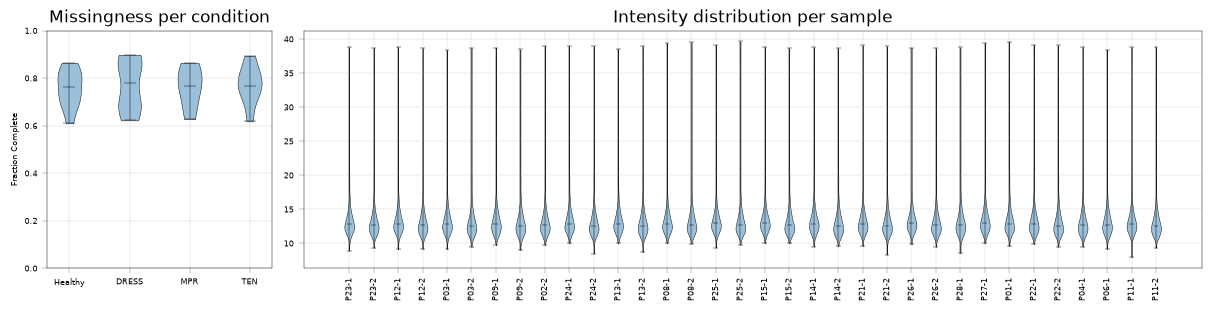

In [8]:
fig, axm = apt.pl.create_figure(
    1, 2, gridspec_kwargs={"width_ratios": [0.2, 0.8]}, figsize=(12, 3)
)
apt.pl.violinplot(
    ax=axm[0], data=adata, grouping_column="condition", value_column="fraction_complete"
)
apt.pl.label_axes(ax=axm[0], ylabel="Fraction Complete")
axm[0].set_ylim(0, 1)


apt.pl.violinplot(
    ax=axm[1],
    data=adata.T,
    direct_columns=adata.obs.index.tolist(),
)
_ = axm[1].set_xticklabels(
    adata.obs["patient_id"] + "-" + adata.obs["replicate_nr"].astype(str), rotation=90
)  # Set the new xtick labels

axm[0].set_title("Missingness per condition")
axm[1].set_title("Intensity distribution per sample")

plt.show()

Both metrics are consistent across the full cohort, indicating homogeneous sample preparation and measurement quality. We therefore retain all samples and proceed to feature-level filtering.

### Feature-level quality control

#### Feature completeness 
Features that are missing in a large fraction of samples carry little statistical support and can destabilize downstream analyses. We therefore flag and remove highly incomplete features. Typical missingness thresholds range from 50% to 80%; here we retain features that are quantified in at least 70% of the samples within any condition.

> **Note:** Missingness should be assessed within biological groups rather than globally. A feature that is absent in most samples but consistently detected within a single condition can be highly informative, as its missingness reflects genuine condition-specific presence rather than a lack of statistical support. For this reason, we evaluate completeness per condition and keep a feature if it passes the threshold in any condition (`keep_strategy="any"`), which avoids discarding such condition-specific markers.

In [9]:
adata = apt.pp.filter_data_completeness(
    adata, group_column="condition", max_missing=0.3, action="flag", keep_strategy="any"
)

INFO:root:pp.filter_data_completeness(): flag 784 / 4460 features with >0.30 missing.


#### Contaminants
In other cases, clinical samples might be contaminated with blood or classical contaminants like Keratins. We do not detect blood in the provided samples and Keratins are expected features, as we are working with skin samples. Thus, we proceed with the analysis.

In [10]:
assert "HBB" not in adata.var["genes"]

### Aggregate

The original publication aggregated replicates per patient. We mean-aggregate the replicates per patient and log-transform the data, which we will use for downstream analysis.

In [11]:
adata_agg = agg(adata, group_column="patient_id", layer="raw")

# Add metadata
# Subset to patient-level metadata
patient_metadata = (
    metadata[["patient_id", "condition"]]
    .drop_duplicates()
    .set_index("patient_id", drop=False)
    .rename_axis(index=None)
)
adata_agg = apt.pp.add_metadata(adata_agg, incoming_metadata=patient_metadata, axis=0)

adata_agg.layers["raw"] = adata_agg.X.copy()
apt.pp.nanlog(adata_agg)

In [12]:
# Subset to proteins with >30% completeness in any condition
adata_agg = adata_agg[:, adata_agg.var["passed_threshold_missing_values"]].copy()

### Imputation

Several downstream analyses, most notably principal component analysis, require a complete data matrix without missing values. We therefore impute the remaining missing values using a Gaussian imputation strategy, which draws imputed values from a down-shifted normal distribution to emulate low-abundance measurements below the detection limit. As imputation introduces artificial values, we recommend working with unimputed data whenever possible and restrict imputation to those analysis steps that strictly require a complete matrix.

In [13]:
adata_agg.layers["imputed"] = adata_agg.X.copy()
apt.pp.impute_gaussian(adata_agg, layer="imputed")

### PCA

To investigate the latent structure of the data, we compute a principal component analysis:

In [14]:
apt.tl.pca(adata_agg, layer="imputed")

INFO:alphapepttools.tl.embeddings:computing PCA


/Users/lucas-diedrich/mamba/envs/npdvp-at/lib/python3.13/functools.py:934: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


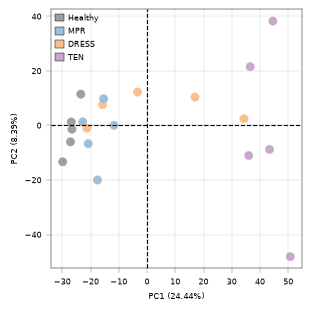

In [15]:
fig, axm = apt.pl.create_figure(1, 1, figsize=(3, 3))
apt.pl.plot_pca(
    adata_agg,
    method="pca",
    ax=axm[0],
    color_map_column="condition",
    color_dict=COLOR_MAP,
    legend="auto",
)
apt.pl.add_lines(ax=axm[0], intercepts=0, linetype="vline")
apt.pl.add_lines(ax=axm[0], intercepts=0, linetype="hline")

Samples separate by severity of the disease in PC1.

### Differential expression analysis

To identify proteins that are differentially expressed between healthy and diseased tissue, we perform a two-sample t-test and correct the resulting p-values for multiple testing.

Here, we compare healthy tissue against the most severe condition (TEN). We subset the data to these two conditions and restrict the analysis to proteins with sufficient evidence (>70% completeness) in both conditions.

In [16]:
adata_agg_ten = adata_agg[adata_agg.obs["condition"].isin(["Healthy", "TEN"])].copy()
adata_agg_ten = apt.pp.filter_data_completeness(
    adata_agg_ten,
    max_missing=0.3,
    group_column="condition",
    groups=["Healthy", "TEN"],
    keep_strategy="all",
    action="drop",
)

INFO:root:pp.filter_data_completeness(): drop 767 / 3676 features with >0.30 missing.


In [17]:
diff_exp = apt.tl.diff_exp_ttest(
    adata_agg_ten, between_column="condition", comparison=("TEN", "Healthy")
)
diff_exp = diff_exp.merge(adata.var, left_index=True, right_index=True)
diff_exp = diff_exp.set_index("genes")

INFO:alphapepttools.tl.utils:Number of samples for TEN: 5
INFO:alphapepttools.tl.utils:Number of samples for Healthy: 5


Comparing groups: TEN vs Healthy


<>:11: SyntaxWarning: invalid escape sequence '\l'
<>:11: SyntaxWarning: invalid escape sequence '\l'
/var/folders/py/838_q5nd6594y27wbrpkhl3h0000gn/T/ipykernel_14724/1100712591.py:11: SyntaxWarning: invalid escape sequence '\l'
  plt.xlabel("$\log_{2}{FC}$\nHealthy $\longleftrightarrow$ TEN")


Text(0.5, 29.33658854166667, '$\\log_{2}{FC}$\nHealthy $\\longleftrightarrow$ TEN')

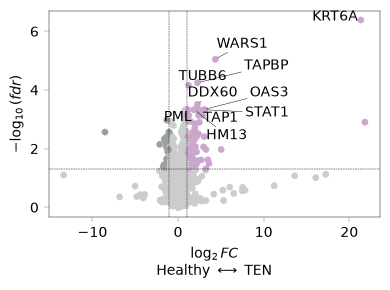

In [18]:
dc.pl.volcano(
    diff_exp,
    x="log2fc",
    y="fdr",
    top=10,
    thr_stat=1,
    color_pos="#CBA7CE",
    color_neg="#999FA3",
    color_null="#cccccc",
)
plt.xlabel("$\log_{2}{FC}$\nHealthy $\longleftrightarrow$ TEN")

The proteins most strongly upregulated in TEN relative to healthy individuals include WARS1 (interferon-gamma response), STAT1, TAPBP, and further major histocompatibility complex class I proteins, which are typical interferon-response genes.

## Write results

In [ ]:
adata.write_zarr("../../results/nordmann2025_keratinocytes.adata.zarr")

In [ ]:
diff_exp.to_csv(
    "../../results/differential-expression-results.TEN-healthy.tsv",
    sep="\t",
    index=True,
)

## Integration with spatial information

For the integration of proteomics data with the spatial component it is necessary to map the measurement back to a specific spatial location. This is not possible with the given data, as it represents minibulk measurements of dissected cells across a whole tissue section. 

If there is a direct mapping between MS-measurements and spatial information possible, users can add the obtained anndata object to the spatialdata object of the [image analysis](../image-analysis/harpy.ipynb). 

How to integrate proteomics data with the available spatial information can be learned in these publicly available tutorials:

- [alphapepttools](https://mannlabs.github.io/alphapepttools/notebooks/studies/study_04_scDVP.html)
- [openDVP](https://coscialab.github.io/openDVP/Tutorials/T3_ProteomicsIntegration.html)
- [dvp-io](https://dvp-io.readthedocs.io/en/latest/tutorials/004_scdvp.html)

## References

^[Nordmann et al.: Nordmann, T. M. et al. Spatial proteomics identifies JAKi as treatment for a lethal skin disease. Nature 1–9 (2024) doi:10.1038/s41586-024-08061-0.]

^[scverse: Virshup, I. et al. The scverse project provides a computational ecosystem for single-cell omics data analysis. Nat Biotechnol 41, 604–606 (2023).]

^[anndata: Virshup, I., Rybakov, S., Theis, F. J., Angerer, P. & Wolf, F. A. anndata: Annotated data. 2021.12.16.473007 Preprint at https://doi.org/10.1101/2021.12.16.473007 (2021).]

^[alphapepttools: Brennsteiner, V., Diedrich, L., Ben-Moshe, S., Schwörer, M. & Mann, M. alphapepttools [Computer software]. https://github.com/MannLabs/alphapepttools]

^[decoupler: Badia-i-Mompel P., Vélez Santiago J., Braunger J., Geiss C., Dimitrov D., Müller-Dott S., Taus P., Dugourd A., Holland C.H., Ramirez Flores R.O. and Saez-Rodriguez J. decoupleR: Ensemble of computational methods to infer biological activities from omics data. Bioinformatics Advances (2022) doi:10.1093/bioadv/vbac016.]

^[openDVP: https://coscialab.github.io/openDVP/Tutorials/T2_DownstreamProteomics.html]

^[MSstats: Choi, M. et al. MSstats: an R package for statistical analysis of quantitative mass spectrometry-based proteomic experiments. Bioinformatics 30 (2014).]

^[scp: Vanderaa, C. & Gatto, L. The current state of single-cell proteomics data analysis. Current Protocols 3 (1): e658 (2023) doi:10.1002/cpz1.658.]

^[Single-cell best practices: Heumos, L. et al. Best practices for single-cell analysis across modalities. Nat Rev Genet 24, 550–572 (2023).]

## Session Info 

In [19]:
from session_info2 import session_info

session_info(dependencies=True)

Package,Version
alphapepttools,0.2.1.dev0 (0.2.1-dev0)
anndata,0.13.2
decoupler,2.2.0
numpy,2.4.6
pandas,3.0.3
matplotlib,3.11.0
scipy,1.18.0
Component,Info
Python,"3.13.14 | packaged by conda-forge | (main, Jun 12 2026, 09:44:24) [Clang 19.1.7 ]"
OS,macOS-26.5.2-arm64-arm-64bit-Mach-O
